# Analytic Task 4 – Fouls Drawn Analysis

## Analytic Question

Among forwards and midfielders who played in FIFA World Cup 2026, what was the mean number of fouls drawn? Was there a significant difference in mean fouls drawn between forwards and midfielders? 

Forward players play mainly in attacking roles compared to midfielders during a game. They also tend to dive for fouls more often when attacking but midfielders are the ones who mostly have the ball, give passes and get challenged while in any area on the pitch. This study wants to find out if forwards draw significantly more fouls than midfielders during FIFA world cup 2026. 

## Data Source

The data used for this project is sourced from FBref FIFA World Cup 2026 Player Miscellaneous Statistics, which was one of the approved data sources listed in the project brief. 

The main variables required for this analysis are:

- **Player** – player name
- **Pos** – player's position
- **90s** – playing time measured in 90-minute units
- **Fld** – total number of fouls drawn

Only players who appeared in the tournament will be considered. For the position comparison, players classified as forwards (FW) and midfielders (MF) will be used.

The FBref data was scraped as an Excel file (.xls). It will first be converted to CSV format using Python. Data wrangling, cleaning, sampling, descriptive statistics, confidence interval and hypothesis testing and visualisations will then be performed. 

In [2]:
import pandas as pd

# Load the original FBref Player Miscellaneous Statistics file
file_path = "Player Miscellaneous.xls"

df = pd.read_html(file_path)[0]

print("Original dataset shape:", df.shape)
display(df.head())

Original dataset shape: (499, 20)


Unnamed: 0_level_0  Unnamed: 1_level_0 Unnamed: 2_level_0  \
                  Rk              Player                Pos   
0                  1    Brenden Aaronson                 MF   
1                  2      Thelo Aasgaard                 MF   
2                  3    Hamza Abdelkarim                 FW   
3                  4  Hossam Abdelmaguid                 DF   
4                  5  Mohamed Abdelmonem                 DF   

  Unnamed: 3_level_0 Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0  \
               Squad                Age               Born                90s   
0             us USA                 25               2000                0.8   
1          no Norway                 24               2002                1.0   
2           eg Egypt                 18               2008                0.7   
3           eg Egypt                 25               2001                0.7   
4           eg Egypt                 27               1999                0.2   

  Performance                                                     \
         CrdY CrdR 2CrdY Fls Fld Off Crs Int TklW PKwon PKcon OG   
0           0    0     0   2   1   0   1   0    1   NaN   NaN  0   
1           0    0     0   0   3   0   0   3    1   NaN   NaN  0   
2           0    0     0   2   0   0   0   0    0   NaN   NaN  0   
3           0    0     0   1   0   0   0   1    0   NaN   NaN  0   
4           0    0     0   1   0   0   0   0    0   NaN   NaN  0   

  Unnamed: 19_level_0  
              Matches  
0             Matches  
1             Matches  
2             Matches  
3             Matches  
4             Matches

In [3]:

df.columns = [col[1] if isinstance(col, tuple) else col for col in df.columns]

print("Column names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

display(df.head())

Column names:
['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'PKwon', 'PKcon', 'OG', 'Matches']

Dataset shape:
(499, 20)


,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,2,1,0,1,0,1,NaN,NaN,0,Matches
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,0,3,0,0,3,1,NaN,NaN,0,Matches
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,2,0,0,0,0,0,NaN,NaN,0,Matches
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,1,0,0,0,1,0,NaN,NaN,0,Matches
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,1,0,0,0,0,0,NaN,NaN,0,Matches


In [4]:


raw_file = "task4_player_miscellaneous_raw.csv"

df.to_csv(raw_file, index=False)

print("Raw CSV created successfully!")
print("File name:", raw_file)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Raw CSV created successfully!
File name: task4_player_miscellaneous_raw.csv
Rows: 499
Columns: 20


In [5]:

raw_df = pd.read_csv("task4_player_miscellaneous_raw.csv")

print("Dataset shape:", raw_df.shape)

print("\nData types:")
print(raw_df.dtypes)

print("\nMissing values:")
print(raw_df.isnull().sum())

print("\nDuplicate rows:")
print(raw_df.duplicated().sum())

print("\nPlayer position categories:")
print(raw_df['Pos'].value_counts())

display(raw_df.head())

Dataset shape: (499, 20)

Data types:
Rk           int64
Player      object
Pos         object
Squad       object
Age          int64
Born         int64
90s        float64
CrdY         int64
CrdR         int64
2CrdY        int64
Fls          int64
Fld          int64
Off          int64
Crs          int64
Int          int64
TklW         int64
PKwon      float64
PKcon      float64
OG           int64
Matches     object
dtype: object

Missing values:
Rk           0
Player       0
Pos          0
Squad        0
Age          0
Born         0
90s          0
CrdY         0
CrdR         0
2CrdY        0
Fls          0
Fld          0
Off          0
Crs          0
Int          0
TklW         0
PKwon      499
PKcon      499
OG           0
Matches      0
dtype: int64

Duplicate rows:
0

Player position categories:
Pos
MF       163
DF       150
FW        82
FW,MF     38
GK        26
MF,FW     16
DF,MF     15
MF,DF      7
DF,FW      2
Name: count, dtype: int64


,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,2,1,0,1,0,1,NaN,NaN,0,Matches
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,0,3,0,0,3,1,NaN,NaN,0,Matches
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,2,0,0,0,0,0,NaN,NaN,0,Matches
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,1,0,0,0,1,0,NaN,NaN,0,Matches
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,1,0,0,0,0,0,NaN,NaN,0,Matches


In [6]:

task4 = raw_df[['Player', 'Pos', '90s', 'Fld']].copy()

print("Selected variables:")
print(task4.columns.tolist())

print("\nDataset shape before cleaning:")
print(task4.shape)

print("\nMissing values:")
print(task4.isnull().sum())

print("\nPosition categories:")
print(task4['Pos'].value_counts())

print("\nFouls Drawn summary:")
print(task4['Fld'].describe())

display(task4.head(10))

Selected variables:
['Player', 'Pos', '90s', 'Fld']

Dataset shape before cleaning:
(499, 4)

Missing values:
Player    0
Pos       0
90s       0
Fld       0
dtype: int64

Position categories:
Pos
MF       163
DF       150
FW        82
FW,MF     38
GK        26
MF,FW     16
DF,MF     15
MF,DF      7
DF,FW      2
Name: count, dtype: int64

Fouls Drawn summary:
count    499.000000
mean       2.244489
std        2.768212
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       18.000000
Name: Fld, dtype: float64


,Player,Pos,90s,Fld
0,Brenden Aaronson,MF,0.8,1
1,Thelo Aasgaard,MF,1.0,3
2,Hamza Abdelkarim,FW,0.7,0
3,Hossam Abdelmaguid,DF,0.7,0
4,Mohamed Abdelmonem,DF,0.2,0
5,Ali Abdi,DF,3.0,1
6,Saud Abdulhamid,DF,3.0,2
7,Abdulla Abdullaev,DF,2.0,1
8,Yusuf Abdurisag,FW,1.1,2
9,Husam Abu Dahab,DF,2.0,1


In [7]:

cleaned_df = task4[task4['90s'] > 0].copy()


cleaned_df = cleaned_df[cleaned_df['Pos'].isin(['FW', 'MF'])].copy()


cleaned_df.reset_index(drop=True, inplace=True)

print("Original rows:", len(task4))
print("Cleaned rows:", len(cleaned_df))
print("Rows removed:", len(task4) - len(cleaned_df))

print("\nPlayers by position:")
print(cleaned_df['Pos'].value_counts())

print("\nMissing values after cleaning:")
print(cleaned_df.isnull().sum())

print("\nFirst 10 rows of cleaned dataset:")
display(cleaned_df.head(10))

Original rows: 499
Cleaned rows: 235
Rows removed: 264

Players by position:
Pos
MF    156
FW     79
Name: count, dtype: int64

Missing values after cleaning:
Player    0
Pos       0
90s       0
Fld       0
dtype: int64

First 10 rows of cleaned dataset:


,Player,Pos,90s,Fld
0,Brenden Aaronson,MF,0.8,1
1,Thelo Aasgaard,MF,1.0,3
2,Hamza Abdelkarim,FW,0.7,0
3,Yusuf Abdurisag,FW,1.1,2
4,ChÃ© Adams,FW,1.6,2
5,Jayden Adams,MF,1.3,0
6,Tyler Adams,MF,3.8,6
7,Ali Ahmed,MF,2.6,5
8,Yunus AkgÃ¼n,MF,1.0,1
9,Maghnes Akliouche,MF,0.1,0


In [8]:


cleaned_file = "task4_fouls_drawn_cleaned.csv"

cleaned_df.to_csv(cleaned_file, index=False)

print("Cleaned CSV created successfully!")
print("File name:", cleaned_file)
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

display(cleaned_df.head())

Cleaned CSV created successfully!
File name: task4_fouls_drawn_cleaned.csv
Rows: 235
Columns: 4


,Player,Pos,90s,Fld
0,Brenden Aaronson,MF,0.8,1
1,Thelo Aasgaard,MF,1.0,3
2,Hamza Abdelkarim,FW,0.7,0
3,Yusuf Abdurisag,FW,1.1,2
4,ChÃ© Adams,FW,1.6,2


In [9]:

forwards = cleaned_df[cleaned_df['Pos'] == 'FW']
midfielders = cleaned_df[cleaned_df['Pos'] == 'MF']

print("Available forwards:", len(forwards))
print("Available midfielders:", len(midfielders))


sample_fw = forwards.sample(n=50, random_state=42)
sample_mf = midfielders.sample(n=50, random_state=42)


sample_df = pd.concat([sample_fw, sample_mf])


sample_df = sample_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nForward sample:", len(sample_fw))
print("Midfielder sample:", len(sample_mf))
print("Total sample:", len(sample_df))

print("\nSample distribution:")
print(sample_df['Pos'].value_counts())

display(sample_df.head(10))

Available forwards: 79
Available midfielders: 156

Forward sample: 50
Midfielder sample: 50
Total sample: 100

Sample distribution:
Pos
MF    50
FW    50
Name: count, dtype: int64


,Player,Pos,90s,Fld
0,Ali Jasim,MF,1.4,0
1,Ousmane DembÃ©lÃ©,MF,6.6,4
2,Ãlvaro Fidalgo,MF,1.1,2
3,Amirhossein Hosseinzadeh,FW,0.2,0
4,JuliÃ¡n Ãlvarez,FW,6.7,4
5,Jordan Ayew,FW,3.3,7
6,Almoez Ali,FW,0.2,0
7,Hicham Boudaoui,MF,1.4,1
8,Santiago GimÃ©nez,FW,1.0,3
9,MojmÃ­r Chytil,FW,0.1,0


In [10]:


sample_file = "task4_sample_100_players.csv"

sample_df.to_csv(sample_file, index=False)

print("Sample CSV created successfully!")
print("File name:", sample_file)
print("Rows:", sample_df.shape[0])
print("Columns:", sample_df.shape[1])

print("\nSample distribution:")
print(sample_df['Pos'].value_counts())

display(sample_df.head())

Sample CSV created successfully!
File name: task4_sample_100_players.csv
Rows: 100
Columns: 4

Sample distribution:
Pos
MF    50
FW    50
Name: count, dtype: int64


,Player,Pos,90s,Fld
0,Ali Jasim,MF,1.4,0
1,Ousmane DembÃ©lÃ©,MF,6.6,4
2,Ãlvaro Fidalgo,MF,1.1,2
3,Amirhossein Hosseinzadeh,FW,0.2,0
4,JuliÃ¡n Ãlvarez,FW,6.7,4


In [11]:


print("Overall Sample - Fouls Drawn")
print(sample_df['Fld'].describe())

print("\nOverall Mean:", round(sample_df['Fld'].mean(), 2))
print("Overall Median:", round(sample_df['Fld'].median(), 2))
print("Overall Standard Deviation:", round(sample_df['Fld'].std(), 2))
print("Overall Variance:", round(sample_df['Fld'].var(), 2))

Overall Sample - Fouls Drawn
count    100.000000
mean       2.240000
std        2.670906
min        0.000000
25%        0.000000
50%        2.000000
75%        3.000000
max       18.000000
Name: Fld, dtype: float64

Overall Mean: 2.24
Overall Median: 2.0
Overall Standard Deviation: 2.67
Overall Variance: 7.13


In [12]:


summary_table = sample_df.groupby('Pos')['Fld'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std_Dev='std',
    Variance='var',
    Minimum='min',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Maximum='max'
).round(2)

print("Descriptive Statistics by Position:")
display(summary_table)

Descriptive Statistics by Position:


,Count,Mean,Median,Std_Dev,Variance,Minimum,Q1,Q3,Maximum
Pos,,,,,,,,,
FW,50,2.08,1.0,2.30,5.30,0,0.25,3.0,11
MF,50,2.40,2.0,3.01,9.06,0,0.25,3.0,18


In [13]:


summary_file = "task4_summary_table.csv"

summary_table.to_csv(summary_file)

print("Summary table saved successfully!")
print("File name:", summary_file)

Summary table saved successfully!
File name: task4_summary_table.csv


In [14]:
import numpy as np
from scipy import stats


def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    se = std / np.sqrt(n)

    t_critical = stats.t.ppf((1 + confidence) / 2, df=n - 1)

    lower = mean - t_critical * se
    upper = mean + t_critical * se

    return n, mean, std, se, lower, upper



overall_ci = confidence_interval(sample_df['Fld'])


fw_ci = confidence_interval(sample_df[sample_df['Pos'] == 'FW']['Fld'])


mf_ci = confidence_interval(sample_df[sample_df['Pos'] == 'MF']['Fld'])


print("95% CONFIDENCE INTERVALS FOR FOULS DRAWN\n")

print("Overall Sample")
print(f"Mean: {overall_ci[1]:.2f}")
print(f"Standard Error: {overall_ci[3]:.3f}")
print(f"95% CI: ({overall_ci[4]:.2f}, {overall_ci[5]:.2f})")

print("\nForwards (FW)")
print(f"Mean: {fw_ci[1]:.2f}")
print(f"Standard Error: {fw_ci[3]:.3f}")
print(f"95% CI: ({fw_ci[4]:.2f}, {fw_ci[5]:.2f})")

print("\nMidfielders (MF)")
print(f"Mean: {mf_ci[1]:.2f}")
print(f"Standard Error: {mf_ci[3]:.3f}")
print(f"95% CI: ({mf_ci[4]:.2f}, {mf_ci[5]:.2f})")

95% CONFIDENCE INTERVALS FOR FOULS DRAWN

Overall Sample
Mean: 2.24
Standard Error: 0.267
95% CI: (1.71, 2.77)

Forwards (FW)
Mean: 2.08
Standard Error: 0.326
95% CI: (1.43, 2.73)

Midfielders (MF)
Mean: 2.40
Standard Error: 0.426
95% CI: (1.54, 3.26)


In [19]:
# Hypotheses for the two-sample comparison

alpha = 0.05

print("HYPOTHESES")
print("--------------------------------------------")
print("H0: μFW = μMF")
print("There is no statistically significant difference")
print("in mean fouls drawn between forwards and midfielders.")

print("\nH1: μFW ≠ μMF")
print("There is a statistically significant difference")
print("in mean fouls drawn between forwards and midfielders.")

print(f"\nSignificance Level (alpha): {alpha}")

HYPOTHESES
--------------------------------------------
H0: μFW = μMF
There is no statistically significant difference
in mean fouls drawn between forwards and midfielders.

H1: μFW ≠ μMF
There is a statistically significant difference
in mean fouls drawn between forwards and midfielders.

Significance Level (alpha): 0.05


In [20]:

fw_data = sample_df[sample_df['Pos'] == 'FW']['Fld']
mf_data = sample_df[sample_df['Pos'] == 'MF']['Fld']

print("ASSUMPTION CHECK")
print("--------------------------------------------")


print("Sample Sizes:")
print("Forwards:", len(fw_data))
print("Midfielders:", len(mf_data))


fw_skew = fw_data.skew()
mf_skew = mf_data.skew()

print("\nSkewness:")
print(f"Forwards: {fw_skew:.2f}")
print(f"Midfielders: {mf_skew:.2f}")


fw_variance = fw_data.var()
mf_variance = mf_data.var()

print("\nSample Variances:")
print(f"Forwards: {fw_variance:.2f}")
print(f"Midfielders: {mf_variance:.2f}")


print("\nIndependence:")
print("The forward and midfielder samples contain different players,")
print("so the two groups are treated as independent.")


print("\nTest Selection:")
print("Welch's independent two-sample t-test will be used.")
print("It does not require the two population variances to be equal.")

ASSUMPTION CHECK
--------------------------------------------
Sample Sizes:
Forwards: 50
Midfielders: 50

Skewness:
Forwards: 1.77
Midfielders: 3.12

Sample Variances:
Forwards: 5.30
Midfielders: 9.06

Independence:
The forward and midfielder samples contain different players,
so the two groups are treated as independent.

Test Selection:
Welch's independent two-sample t-test will be used.
It does not require the two population variances to be equal.


In [21]:
from scipy.stats import ttest_ind

# Welch's independent two-sample t-test
t_stat, p_value = ttest_ind(
    fw_data,
    mf_data,
    equal_var=False
)

alpha = 0.05

print("WELCH'S TWO-SAMPLE T-TEST")
print("--------------------------------------------")

print(f"Forward Mean: {fw_data.mean():.2f}")
print(f"Midfielder Mean: {mf_data.mean():.2f}")
print(f"Mean Difference (FW - MF): {fw_data.mean() - mf_data.mean():.2f}")

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (alpha): {alpha}")

# Statistical decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("There is a statistically significant difference in mean fouls drawn")
    print("between forwards and midfielders.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is insufficient evidence of a statistically significant difference")
    print("in mean fouls drawn between forwards and midfielders.")

WELCH'S TWO-SAMPLE T-TEST
--------------------------------------------
Forward Mean: 2.08
Midfielder Mean: 2.40
Mean Difference (FW - MF): -0.32

t-statistic: -0.597
p-value: 0.5519
Significance Level (alpha): 0.05

Decision: Fail to reject H0
There is insufficient evidence of a statistically significant difference
in mean fouls drawn between forwards and midfielders.


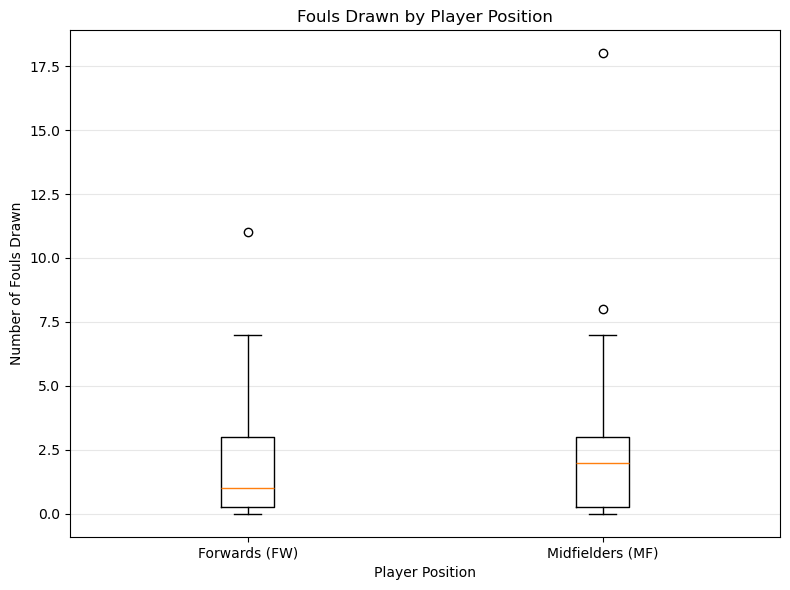

Boxplot saved successfully as task4_fouls_boxplot.png


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.boxplot(
    [fw_data, mf_data],
    tick_labels=['Forwards (FW)', 'Midfielders (MF)']
)

plt.title('Fouls Drawn by Player Position')
plt.xlabel('Player Position')
plt.ylabel('Number of Fouls Drawn')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save before displaying
plt.savefig(
    "task4_fouls_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Boxplot saved successfully as task4_fouls_boxplot.png")

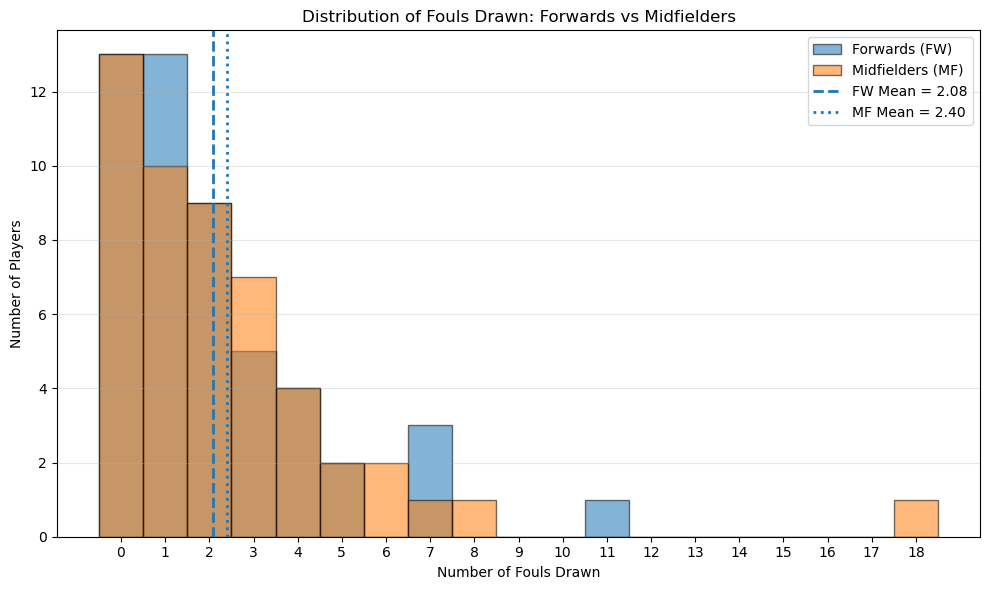

Histogram saved successfully as task4_fouls_histogram.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create common bins for both groups
max_fouls = int(sample_df['Fld'].max())
bins = np.arange(-0.5, max_fouls + 1.5, 1)

plt.figure(figsize=(10, 6))

# Forward distribution
plt.hist(
    fw_data,
    bins=bins,
    alpha=0.55,
    label='Forwards (FW)',
    edgecolor='black'
)

# Midfielder distribution
plt.hist(
    mf_data,
    bins=bins,
    alpha=0.55,
    label='Midfielders (MF)',
    edgecolor='black'
)

# Mean reference lines
plt.axvline(
    fw_data.mean(),
    linestyle='--',
    linewidth=2,
    label=f'FW Mean = {fw_data.mean():.2f}'
)

plt.axvline(
    mf_data.mean(),
    linestyle=':',
    linewidth=2,
    label=f'MF Mean = {mf_data.mean():.2f}'
)

plt.title('Distribution of Fouls Drawn: Forwards vs Midfielders')
plt.xlabel('Number of Fouls Drawn')
plt.ylabel('Number of Players')

plt.xticks(range(0, max_fouls + 1))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save BEFORE displaying
plt.savefig(
    "task4_fouls_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Histogram saved successfully as task4_fouls_histogram.png")

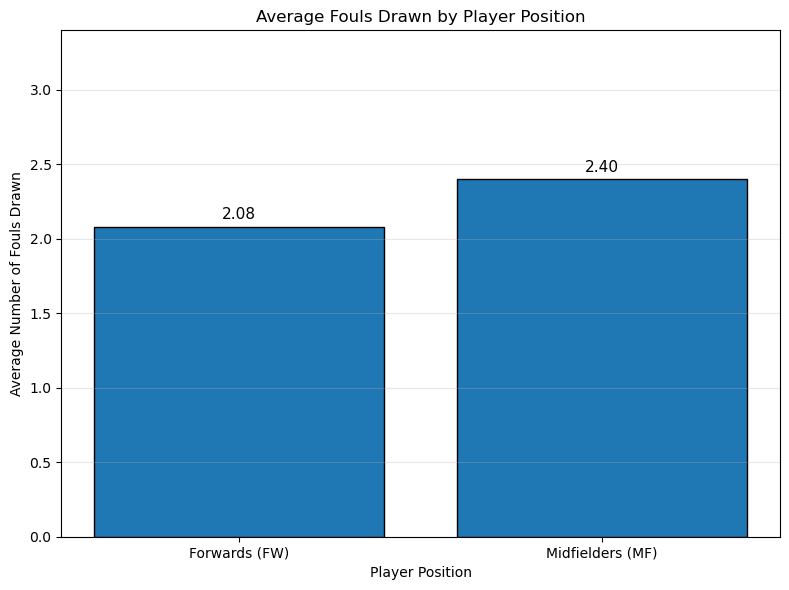

Bar chart saved successfully as task4_fouls_mean_comparison.png


In [24]:

mean_fouls = sample_df.groupby('Pos')['Fld'].mean()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['Forwards (FW)', 'Midfielders (MF)'],
    [mean_fouls['FW'], mean_fouls['MF']],
    edgecolor='black'
)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{height:.2f}',
        ha='center',
        fontsize=11
    )

plt.title('Average Fouls Drawn by Player Position')
plt.xlabel('Player Position')
plt.ylabel('Average Number of Fouls Drawn')

plt.ylim(0, max(mean_fouls) + 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()


plt.savefig(
    "task4_fouls_mean_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bar chart saved successfully as task4_fouls_mean_comparison.png")

## Results, Interpretation and Conclusion

We analyzed a stratified random sample of 100 FIFA World Cup 2026 players, 50 forwards (FW) and 50 midfielders (MF). The grand mean number of fouls drawn was 2.24. The average number of fouls for forwards was 2.08 and for midfielders was a bit higher at 2.40.

The overall mean was 2.24 fouls drawn (95% CI 1.71 to 2.77 fouls drawn). The corresponding 95% confidence intervals were 1.43–2.73 for forwards and 1.54–3.26 for midfielders.

Welch’s independent two-sample t-test was conducted to determine whether the difference between forwards and midfielders was statistically significant at the significance level of α = 0.05. The test’s t-statistic was -0.597 and the p-value was 0.5519. The null hypothesis was not rejected, as the p-value was greater than 0.05. Therefore, there is not enough statistical evidence to say that the mean number of fouls drawn by forwards and midfielders are different.

These findings are supported by the visualizations. The bar chart shows that the sample mean for midfielders was slightly higher than for the forwards. The boxplot and histogram show a large overlap between the two groups. The distributions were positively skewed, especially for midfielders, with skewness values of 1.77 for forwards and 3.12 for midfielders.

### Conclusion

The forwards and midfielders sampled committed an average of 2.24 fouls. Although the sample mean for midfielders was higher (2.40) than for forwards (2.08), the observed difference of 0.32 fouls was not statistically significant (p = 0.5519). This analysis therefore does not provide enough evidence that player position, i.e., forward versus midfielder, is associated with a difference in the mean fouls drawn in the FIFA World Cup 2026.
### Limitations

This analysis has several limitations. Only players classified exclusively as FW or MF were included, so players with combined position classifications were excluded. The analysis used a random sample of 50 players from each position rather than all eligible players. Fouls drawn were analysed as tournament totals and therefore may be influenced by differences in playing time between players. In addition, the distributions were positively skewed and contained some relatively high values, particularly among midfielders. These factors should be considered when interpreting the results.